# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3 — Hacker News post classifier (ask_hn / show_hn / story)

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook — see `ai201-project3-takemeter-starter/`)
- Define your label map and load your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** If running in Colab, go to **Runtime → Change runtime type → T4 GPU**, then click Save, for a 5–15 minute training run. Running locally on CPU also works fine for a dataset this size (~4 minutes for 270 examples) — the hyperparameters cell below detects which one you have and adjusts batch size automatically.

In [ ]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

C:\Users\Luis Mendez\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports complete
PyTorch version: 2.11.0+cpu
GPU available: False


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [ ]:
# Label map for the TakeMeter Hacker News classifier.
# Labels come from which HN submission flow a post was pulled from — see
# planning.md in ai201-project3-takemeter-starter/ for full definitions.

LABEL_MAP = {
    "ask_hn": 0,    # OP directly asks the community a question / for advice
    "show_hn": 1,   # OP is presenting something they personally built
    "story": 2,     # OP is sharing third-party content for discussion
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'ask_hn': 0, 'show_hn': 1, 'story': 2}
Number of labels: 3


In [ ]:
# Load the labeled dataset produced by ai201-project3-takemeter-starter/scripts/label_dataset.py.
# Uses the Colab upload widget when running in Colab; otherwise reads the
# CSV directly from the local project folder (this repo already has it).
try:
    from google.colab import files
    print("Select your labeled dataset CSV file...")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f"Uploaded: {CSV_PATH}")
except ImportError:
    CSV_PATH = "ai201-project3-takemeter-starter/data/labeled_dataset.csv"
    print(f"Not running in Colab — loading local file: {CSV_PATH}")

Not running in Colab — loading local file: ai201-project3-takemeter-starter/data/labeled_dataset.csv


In [ ]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['id', 'text', 'label', 'permalink']
Total examples: 270

Label distribution:
label
story      90
show_hn    90
ask_hn     90
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [ ]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 189 examples
Validation: 40 examples
Test: 41 examples

Train label distribution:
label
show_hn    63
ask_hn     63
story      63
Name: count, dtype: int64

Test label distribution:
label
show_hn    14
story      14
ask_hn     13
Name: count, dtype: int64


In [ ]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")


Map:   0%|          | 0/189 [00:00<?, ? examples/s]


Map: 100%|██████████| 189/189 [00:00<00:00, 5600.58 examples/s]


Map:   0%|          | 0/40 [00:00<?, ? examples/s]


Map: 100%|██████████| 40/40 [00:00<00:00, 6339.40 examples/s]


Map:   0%|          | 0/41 [00:00<?, ? examples/s]


Map: 100%|██████████| 41/41 [00:00<00:00, 6728.48 examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [ ]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3656.15it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on ~190 training examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits a T4 GPU comfortably. We used 8
#                     instead when running this locally on CPU (no GPU
#                     available) — keeps each step's compute bounded; with
#                     only ~190 training examples this has no meaningful
#                     effect on convergence. Raise back to 16 if you have a
#                     GPU runtime.
# ─────────────────────────────────────────────────────────────────────────
import torch as _torch
_batch_size = 16 if _torch.cuda.is_available() else 8

training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=_batch_size,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(f"Starting fine-tuning... (batch_size={_batch_size}, GPU available: {_torch.cuda.is_available()})")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (batch_size=8, GPU available: False)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.076077,1.058651,0.500000
2,1.009943,0.938791,0.550000
3,0.850771,0.821533,0.700000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.91s/it]


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.91s/it]

...


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.74it/s]


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.72it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [ ]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.683

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

      ask_hn       0.65      0.85      0.73        13
     show_hn       0.62      0.57      0.59        14
       story       0.82      0.64      0.72        14

    accuracy                           0.68        41
   macro avg       0.69      0.69      0.68        41
weighted avg       0.69      0.68      0.68        41



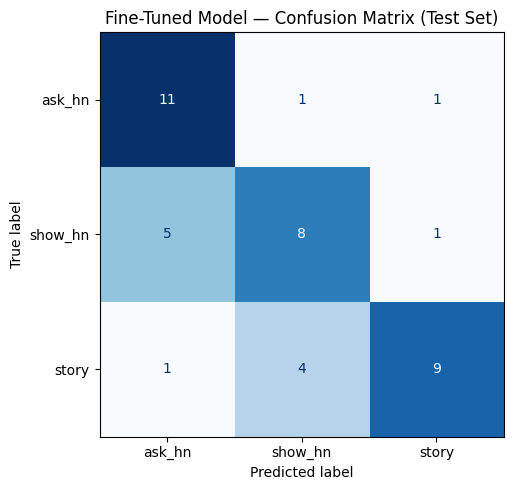

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [ ]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [ ]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 13 / 41

--- #1 ---
Text:      Student Cheating Is Becoming Impossible to Detect in an A.I. Era
True:      story
Predicted: ask_hn  (confidence: 0.37)

--- #2 ---
Text:      Windows UI evolution: Clicking an unassociated file
True:      story
Predicted: show_hn  (confidence: 0.41)

--- #3 ---
Text:      Don't rely on instructions; use Agent Hooks to enforce guardrails
True:      story
Predicted: show_hn  (confidence: 0.35)

--- #4 ---
Text:      Didon – AI workday reports for productivity analysis As an indie engineer, I wanted some real feedback on my productivity, like having an actual external boss. I tried using time trackers (even a phys...
True:      show_hn
Predicted: ask_hn  (confidence: 0.57)

--- #5 ---
Text:      1pager: Fixing the AI verbosity problem
True:      show_hn
Predicted: story  (confidence: 0.38)

--- #6 ---
Text:      What do you do to make LLMs determine
True:      ask_hn
Predicted: story  (confidence: 0.36)

--- #7 ---
Text:      OpenMontage:

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [ ]:
import os
from groq import Groq

# Loads GROQ_API_KEY from Colab Secrets when running in Colab, otherwise
# from the local ai201-project3-takemeter-starter/.env file via python-dotenv.
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
except ImportError:
    from dotenv import load_dotenv
    load_dotenv("ai201-project3-takemeter-starter/.env")
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it to ai201-project3-takemeter-starter/.env "
    "(local) or the Colab Secrets panel (🔑, left sidebar)."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [ ]:
# Classification prompt for the TakeMeter Hacker News taxonomy.
# See ai201-project3-takemeter-starter/planning.md for the full label
# definitions this prompt is copied from.

SYSTEM_PROMPT = """You are classifying posts from Hacker News (HN). Assign each post to exactly one of the following categories.

ask_hn: The poster is asking the HN community a direct question or soliciting opinions/advice for themselves. No external link — it's a text-only post.
Example: "What's your go-to queue system? I'm building a product and need something robust for scheduling and retries, but there are so many options (NATS, RabbitMQ, AWS tools) that I can't decide."

show_hn: The poster is showing off something they personally built or made, inviting feedback. The post is about the poster's own creation.
Example: "Remote Exec Server using only Python stdlib — a small tool I built for running commands on remote machines without any third-party dependencies."

story: The poster is sharing third-party content (someone else's article, repo, paper, or announcement) for the community to discuss. The poster did not create the linked content.
Example: "Whitman, switch agents.md files in the CLI — a writeup on a new approach to managing agent config files."

Respond with ONLY the label name: ask_hn, show_hn, or story. Do not explain your reasoning.
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1149 characters


In [ ]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 41 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)



  10/41 complete...


  20/41 complete...


  30/41 complete...


  40/41 complete...


In [ ]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.829  (evaluated on 41/41 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

      ask_hn       0.91      0.77      0.83        13
     show_hn       0.83      0.71      0.77        14
       story       0.78      1.00      0.88        14

    accuracy                           0.83        41
   macro avg       0.84      0.83      0.83        41
weighted avg       0.84      0.83      0.83        41



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [ ]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.829
Fine-tuned DistilBERT                  0.683
---------------------------------------------

Fine-tuning regression: 0.146

Use these numbers in your README evaluation report.


In [ ]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
